In [35]:
from u_flora.utils.timing import estimate_round_duration_s, apply_duration_jitter

# Deterministic round setup (adjust as needed)
profile = {"computation": 250, "communication": 3200.0}  # ms/sample, kbps
num_samples = 3000
local_epochs = 1
model_size_kb = 6607.0
# model_size_kb = 3140.0

compute_s, comm_s, total_s = estimate_round_duration_s(
    profile=profile,
    num_samples=num_samples,
    local_epochs=local_epochs,
    model_size_kb=model_size_kb,
)

print(f"Deterministic compute_s={compute_s:.3f}, comm_s={comm_s:.3f}, total_s={total_s:.3f}")

Deterministic compute_s=750.000, comm_s=33.035, total_s=783.035


In [36]:
import pandas as pd

# Jitter parameters (from pyproject.toml)
compute_cv = 0.10
comm_cv = 0.25
compute_min_factor = 0.7
comm_min_factor = 0.5
comm_stall_prob = 0.01
comm_stall_factor_min = 1.0
comm_stall_factor_max = 3.0

num_runs = 5000
seed_base = 42

compute_mults = []
comm_mults = []
totals = []
stall_flags = []
jittered_compute_s = []
jittered_comm_s = []

for i in range(num_runs):
    out_compute, out_comm, out_total, meta = apply_duration_jitter(
        compute_s,
        comm_s,
        compute_cv=compute_cv,
        comm_cv=comm_cv,
        compute_min_factor=compute_min_factor,
        comm_min_factor=comm_min_factor,
        comm_stall_prob=comm_stall_prob,
        comm_stall_factor_min=comm_stall_factor_min,
        comm_stall_factor_max=comm_stall_factor_max,
        seed=(seed_base, i, 0),
    )
    compute_mults.append(meta["jitter_compute_mult"])
    comm_mults.append(meta["jitter_comm_mult"])
    totals.append(out_total)
    stall_flags.append(meta["jitter_comm_stall"] > 1.0)
    jittered_compute_s.append(out_compute)
    jittered_comm_s.append(out_comm)

def _quantile(values, q):
    if not values:
        return None
    xs = sorted(values)
    pos = q * (len(xs) - 1)
    lo = int(pos)
    hi = min(lo + 1, len(xs) - 1)
    if lo == hi:
        return xs[lo]
    frac = pos - lo
    return xs[lo] * (1 - frac) + xs[hi] * frac

def _summary(values):
    return {
        "min": min(values),
        "p50": _quantile(values, 0.50),
        "p90": _quantile(values, 0.90),
        "p99": _quantile(values, 0.99),
        "max": max(values),
        "mean": sum(values) / len(values),
    }

summary_compute = _summary(compute_mults)
summary_comm = _summary(comm_mults)
summary_total = _summary(totals)
summary_jittered_compute = _summary(jittered_compute_s)
summary_jittered_comm = _summary(jittered_comm_s)
stall_rate = sum(stall_flags) / len(stall_flags)

print("Compute multiplier summary:", summary_compute)
print("Comm multiplier summary:", summary_comm)
print("Total seconds summary:", summary_total)
print("Jittered compute seconds summary:", summary_jittered_compute)
print("Jittered comm seconds summary:", summary_jittered_comm)
print(f"Mean compute multiplier: {summary_compute['mean']:.4f}")
print(f"Mean comm multiplier: {summary_comm['mean']:.4f}")
print(f"Stall rate: {stall_rate:.3%}")

stats_table = pd.DataFrame(
    [
        {"metric": "compute_mult", **summary_compute},
        {"metric": "comm_mult", **summary_comm},
        {"metric": "jittered_compute_s", **summary_jittered_compute},
        {"metric": "jittered_comm_s", **summary_jittered_comm},
        {"metric": "total_s", **summary_total},
    ]
).set_index("metric")

stats_table

Compute multiplier summary: {'min': 0.7103948817458604, 'p50': 0.9945830314756534, 'p90': 1.1337036587639553, 'p99': 1.2495843501695514, 'max': 1.358350508919693, 'mean': 1.0004066603082038}
Comm multiplier summary: {'min': 0.5, 'p50': 0.9790883613963495, 'p90': 1.3525634228450176, 'p99': 1.842821199105973, 'max': 5.000565068634112, 'mean': 1.0177412587282844}
Total seconds summary: {'min': 567.8825289880609, 'p50': 780.2008025622438, 'p90': 884.7484418003994, 'p99': 971.3939591164681, 'max': 1069.648624138762, 'mean': 783.9260777132417}
Jittered compute seconds summary: {'min': 532.7961613093953, 'p50': 745.9372736067401, 'p90': 850.2777440729662, 'p99': 937.1882626271637, 'max': 1018.7628816897698, 'mean': 750.3049952311528}
Jittered comm seconds summary: {'min': 16.5175, 'p50': 32.344184018728406, 'p90': 44.681932673685154, 'p99': 60.877598312465814, 'max': 165.19366704232786, 'mean': 33.621082482088866}
Mean compute multiplier: 1.0004
Mean comm multiplier: 1.0177
Stall rate: 0.900%

,min,p50,p90,p99,max,mean
metric,,,,,,
compute_mult,0.710395,0.994583,1.133704,1.249584,1.358351,1.000407
comm_mult,0.500000,0.979088,1.352563,1.842821,5.000565,1.017741
jittered_compute_s,532.796161,745.937274,850.277744,937.188263,1018.762882,750.304995
jittered_comm_s,16.517500,32.344184,44.681933,60.877598,165.193667,33.621082
total_s,567.882529,780.200803,884.748442,971.393959,1069.648624,783.926078


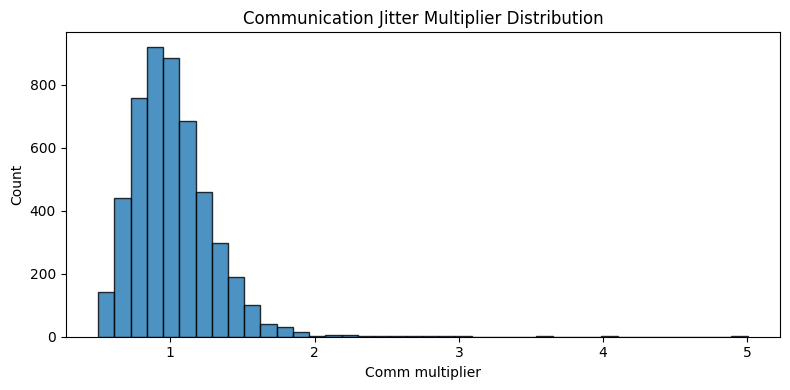

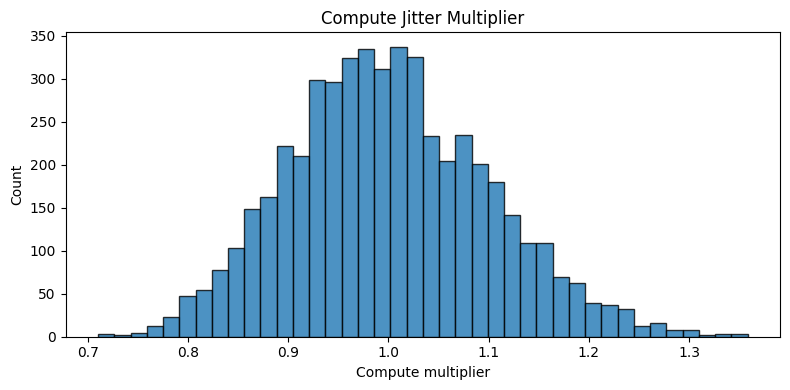

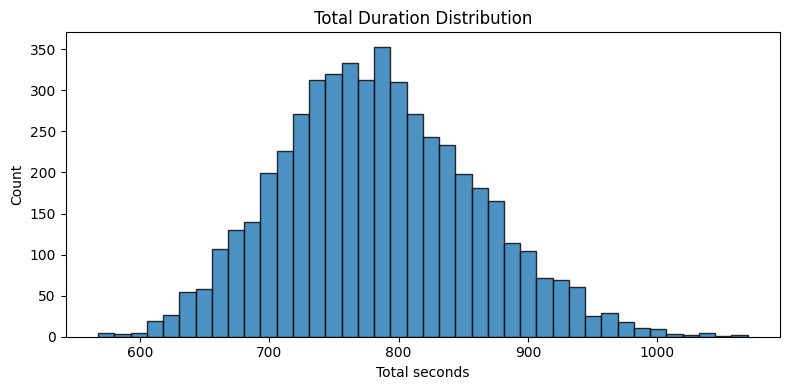

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(comm_mults, bins=40, edgecolor="black", alpha=0.8)
plt.title("Communication Jitter Multiplier Distribution")
plt.xlabel("Comm multiplier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(compute_mults, bins=40, edgecolor="black", alpha=0.8)
plt.title("Compute Jitter Multiplier")
plt.xlabel("Compute multiplier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(totals, bins=40, edgecolor="black", alpha=0.8)
plt.title("Total Duration Distribution")
plt.xlabel("Total seconds")
plt.ylabel("Count")
plt.tight_layout()
plt.show()